# OBLIGATORIO TALLER 2 (IA)
**Martina Barone (302285), Joaquin Chifteian (290464) y Ana Clara Vázquez (282326)**

## Instalación de dependencias y configuración inicial

In [ ]:
print("Iniciando Setup")

# Instalación de dependencias
!pip install numpy==1.26.4
!pip install sentence-transformers --upgrade
!pip install -q langchain langchain-community langchain-pinecone pinecone-client pandas langchain-huggingface huggingface_hub tqdm pypdf langgraph langgraph.prebuilt

# Imports
import os
import pandas as pd
import json
from google.colab import userdata, drive

# drive
drive.mount('/content/drive')

# Configuración de Tokens
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    PINECONE_API_KEY = userdata.get('PINECONE_KEY')
except Exception as e:
    print(f"Error obteniendo tokens de userdata: {e}")
    raise SystemExit("Tokens no encontrados.")

assert HF_TOKEN is not None and len(HF_TOKEN) > 0, "Configurar el secreto 'HF_TOKEN'"
assert PINECONE_API_KEY is not None and len(PINECONE_API_KEY) > 0, "Configurar el secreto 'PINECONE_API_KEY'"

os.environ['HUGGINGFACEHUB_API_TOKEN'] = HF_TOKEN
os.environ['PINECONE_API_KEY'] = PINECONE_API_KEY

print("Instalación y dependencias listas")
print("Tokens cargados correctamente")

print("Finalizado correctamente")

Iniciando Setup
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Instalación y dependencias listas
Tokens cargados correctamente
Finalizado correctamente


En caso de tener los índices ya creados, ejecutar la siguiente celda y omitir la ejecución de 'dataset de películas' y 'Documentos .pdf'

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from pinecone import Pinecone
from langchain_pinecone import PineconeVectorStore

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_DIMENSION = 384

embeddings_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME
)

pc = Pinecone(api_key=PINECONE_API_KEY)

vectorstore_letterboxd = PineconeVectorStore(
    index=pc.Index("letterboxd"),
    embedding=embeddings_model
)

vectorstore_pdfs = PineconeVectorStore(
    index=pc.Index("rag-pdfs-obligatorio"),
    embedding=embeddings_model
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## dataset de películas

### Carga, análisis y limpieza de datos

In [ ]:
print("Iniciando Carga y Análisis de Datos")

# Cargar el dataset CSV
DATASET_FILE = "/content/drive/MyDrive/Obligatorio Taller 2 (IA)/dataset/letterboxd_movies_dataset.csv"

try:
    df = pd.read_csv(DATASET_FILE, encoding='utf-8')
    print(f"Dataset '{DATASET_FILE}' cargado correctamente. Total filas: {len(df)}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{DATASET_FILE}'.")
    raise SystemExit("Archivo CSV no encontrado.")
except pd.errors.ParserError:
    print(f"Error: El archivo '{DATASET_FILE}' tiene un formato CSV inválido.")
    raise SystemExit("Error de formato CSV.")


# Análisis básico
print("\nInformación del DataFrame:")
df.info()

print("\nColumnas con valores nulos (antes de limpiar):")
print(df.isnull().sum())

Iniciando Carga y Análisis de Datos
Dataset '/content/drive/MyDrive/Obligatorio Taller 2 (IA)/dataset/letterboxd_movies_dataset.csv' cargado correctamente. Total filas: 16246

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16246 entries, 0 to 16245
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                16246 non-null  object 
 1   year                 16246 non-null  float64
 2   decade               16246 non-null  int64  
 3   decade_category      16246 non-null  object 
 4   movie_era            16246 non-null  object 
 5   age_years            16246 non-null  float64
 6   age_category         15835 non-null  object 
 7   runtime              16210 non-null  float64
 8   runtime_category     16210 non-null  object 
 9   runtime_percentile   16246 non-null  object 
 10  is_feature_length    16246 non-null  bool   
 11  genres               15084 non-nu

In [ ]:
# Limpieza de datos
df['genres'] = df['genres'].fillna('Genre not specified')
df['primary_genre'] = df['primary_genre'].fillna('Primary genre unknown')
df['country'] = df['country'].fillna('Unknown')
df['language'] = df['language'].fillna('No language')
df['runtime'] = df['runtime'].fillna(0)
df['runtime_category'] = df['runtime_category'].fillna('Not specified')
df['age_category'] = df['age_category'].fillna('Unknown')

# Creación de la columna principal de texto
def construir_texto_pelicula(row):
    text = (f"The film {row['title']} from {row['country']} was released in the year {int(row['year'])} (decade: {row['decade']}s, era: {row['movie_era']}). "
    f"Its duration is {int(row['runtime']) if not pd.isna(row['runtime']) else 'unknown'} minutes. "
    f"It was produced in {row['country'] if pd.notna(row['country']) else 'an unknown country'}, "
    f"and its language is {row['language'] if pd.notna(row['language']) else 'unknown'}. "
    f"The production scale is {row['production_scale']}. "
    f"It belongs to the age category {row['age_category'] if pd.notna(row['age_category']) else 'not specified'}.")

    if pd.notna(row['primary_genre']):
        text += f"Primary genre: {row['primary_genre']}. "

    if row['is_classic']:
      text += "This is a classic film. "

    if row['is_recent']:
        text += "This is a recent release. "

    return text


df["text_content"] = df.apply(construir_texto_pelicula, axis=1)


print("\nLimpieza realizada.")
print("Columna 'text_content' creada.")


Limpieza realizada.
Columna 'text_content' creada.


### Chunking y embeddings

In [ ]:
# Análisis de longitud para justificar chunking
print("\nAnálisis de longitud de 'text_content':")
df['text_length'] = df['text_content'].apply(len)
print(df['text_length'].describe())


Análisis de longitud de 'text_content':
count    16246.000000
mean       293.463868
std         18.679214
min        256.000000
25%        278.000000
50%        291.000000
75%        307.000000
max        392.000000
Name: text_length, dtype: float64


In [ ]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm.auto import tqdm

print("Iniciando Chunking")

# Definición de parámetros de Chunking
CHUNK_SIZE = 500
CHUNK_OVERLAP = 50

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]
)

# Convertir DataFrame a Documentos LangChain
documents = []
for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Creando documentos"):
    metadata = {
        "title": row['title'],
        "year": row['year'],
        "decade": row['decade'],
        "movie_era": row['movie_era'],
        "primary_genre": row['primary_genre'],
        "country": row['country'],
        "language": row['language'],
        "runtime": row['runtime'],
        "production_scale": row['production_scale'],
        "is_classic": row['is_classic'],
        "is_recent": row['is_recent']
    }
    doc = Document(page_content=row['text_content'], metadata=metadata)
    documents.append(doc)

print(f"Se crearon {len(documents)} Documentos LangChain.")

# Aplicar chunking
chunks = text_splitter.split_documents(documents)

for chunk in chunks:
    # asegurar que metadata clave (year, country, etc.) no se pierde
    original = chunk.metadata

    chunk.metadata = {
        "title": original.get("title"),
        "year": original.get("year"),
        "decade": original.get("decade"),
        "movie_era": original.get("movie_era"),
        "primary_genre": original.get("primary_genre"),
        "country": original.get("country"),
        "language": original.get("language"),
        "runtime": original.get("runtime"),
        "production_scale": original.get("production_scale"),
        "is_classic": original.get("is_classic"),
        "is_recent": original.get("is_recent")
    }

print(f"Documentos divididos en {len(chunks)} chunks.")

Iniciando Chunking


Creando documentos:   0%|          | 0/16246 [00:00<?, ?it/s]

Se crearon 16246 Documentos LangChain.
Documentos divididos en 16246 chunks.


In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

print("Iniciando creación de embeddings")

# Configurar modelo de embeddings
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_DIMENSION = 384

print(f"Configurando modelo de embeddings: {EMBEDDING_MODEL_NAME}...")

embeddings_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME
)

print(f"Modelo de embeddings '{EMBEDDING_MODEL_NAME}' configurado.")


Iniciando creación de embeddings
Configurando modelo de embeddings: sentence-transformers/all-MiniLM-L6-v2...
Modelo de embeddings 'sentence-transformers/all-MiniLM-L6-v2' configurado.


### Índice _letterboxd_ en Pinecone

In [ ]:
from langchain_pinecone import PineconeVectorStore
from pinecone import Pinecone, ServerlessSpec
import time

print("Iniciando creación de índice en Pinecone ")

INDEX_NAME = "letterboxd"
METRIC = "cosine" # Métrica que usamos en otros laboratorios

# Inicializar cliente Pinecone
pc = Pinecone(api_key=PINECONE_API_KEY)

# Eliminar índice si ya existe
existing_indexes = [index_info["name"] for index_info in pc.list_indexes()]
if INDEX_NAME in existing_indexes:
    print(f"Eliminando índice existente '{INDEX_NAME}'...")
    pc.delete_index(INDEX_NAME)
    time.sleep(3)

# Crear índice
print(f"Creando índice '{INDEX_NAME}'...")
pc.create_index(
    name=INDEX_NAME,
    dimension=EMBEDDING_DIMENSION,
    metric=METRIC,
    spec=ServerlessSpec(
        cloud="aws",
        region="us-east-1"
    )
)

# Esperar a que el índice esté listo
print("Cargando índice...")
while not pc.describe_index(INDEX_NAME).status['ready']:
    time.sleep(1)
print("Indice disponible")

Iniciando creación de índice en Pinecone 
Eliminando índice existente 'letterboxd'...
Creando índice 'letterboxd'...
Cargando índice...
Indice disponible


In [ ]:
# Conectar al índice
index = pc.Index(INDEX_NAME)
print("Estadísticas iniciales del índice:")
print(index.describe_index_stats())

# Indexar chunks en Pinecone
print("Indexando documentos en Pinecone...")
vectorstore_letterboxd = PineconeVectorStore.from_documents(
    documents=chunks,
    embedding=embeddings_model,
    index_name=INDEX_NAME
)

print("Documentos indexados correctamente")
time.sleep(10)
print("Estadísticas del índice después de indexación:")
print(index.describe_index_stats())

Estadísticas iniciales del índice:
{'dimension': 384,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'total_vector_count': 0,
 'vector_type': 'dense'}
Indexando documentos en Pinecone...
Documentos indexados correctamente
Estadísticas del índice después de indexación:
{'dimension': 384,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'': {'vector_count': 16246}},
 'total_vector_count': 16246,
 'vector_type': 'dense'}


## Documentos .pdf

### Carga y procesamiento de PDFs

In [ ]:
# Cargar los 6 PDFs
from langchain_community.document_loaders import PyPDFLoader
import os

pdf_folder = "/content/drive/MyDrive/Obligatorio Taller 2 (IA)/pdfs"
all_docs = []

for filename in os.listdir(pdf_folder):
    if filename.endswith(".pdf"):
        pdf_path = os.path.join(pdf_folder, filename)
        print(f"Cargando: {filename}")
        loader = PyPDFLoader(pdf_path)
        docs = loader.load()
        print(f"  {len(docs)} páginas cargadas.")
        all_docs.extend(docs)

print(f"\nTotal de documentos cargados: {len(all_docs)} páginas en total.")

Cargando: GPT Improving Language Understanding by Generative Pretraining.pdf
  12 páginas cargadas.
Cargando: Scaling Laws for Neural Language Models.pdf
  30 páginas cargadas.
Cargando: Designing Data-Intensive Applications The Big Ideas Behind Reliable, Scalable, and Maintainable Systems by Martin Kleppmann (z-lib.org).pdf
  613 páginas cargadas.
Cargando: Attention is all you need.pdf
  15 páginas cargadas.
Cargando: 2507.14805v1.pdf
  34 páginas cargadas.
Cargando: Language Models are Few-Shot Learners (GPT3).pdf
  75 páginas cargadas.

Total de documentos cargados: 779 páginas en total.


In [ ]:
import re
import spacy

# Funciones de preprocesamiento (vistas en lab 04)

nlp = spacy.load('en_core_web_sm')

def prepare_text_for_embeddings(content_str):
    """Preprocesar texto para mejorar calidad de embeddings"""
    if content_str is None or content_str.strip() == "":
        return "N/A"

    content_str = re.sub(r'\W', ' ', content_str)

    doc = nlp(content_str.lower())
    lemmatized_tokens = [token.lemma_ for token in doc if not token.is_stop]

    lemmatized_text = ' '.join(lemmatized_tokens)
    return lemmatized_text if lemmatized_text.strip() else "N/A"


def expand_abbreviations(text):
    """Expandir abreviaturas comunes"""
    if text is None or text.strip() == "":
        return "N/A"

    abbreviations = {
        "LLM": "Large Language Model",
        "RAG": "Retrieval-Augmented Generation",
        "SLM": "Small Language Model",
        "HNSW": "Hierarchical Navigable Small Worlds",
        "MMR": "Maximal Marginal Relevance",
        "BERT": "Bidirectional Encoder Representations from Transformers",
        "GPT": "Generative Pre-trained Transformer",
        "NLP": "Natural Language Processing",
        "ML": "Machine Learning",
        "AI": "Artificial Intelligence"
    }
    for abbr, full in abbreviations.items():
        text = re.sub(rf'\b{abbr}\b', full, text)

    return text


def normalize_text(s, sep_token=" \n "):
    """Normalizar texto para consistencia"""
    if s is None or s.strip() == "":
        return "N/A"

    s = re.sub(r'\s+', ' ', s).strip()
    s = re.sub(r". ,","",s)
    s = s.replace("..",".")
    s = s.replace(". .",".")
    s = s.replace("\n", "")
    s = s.strip()

    return s if s else "N/A"

print("Funciones de preprocesamiento definidas")

Funciones de preprocesamiento definidas


In [ ]:
# Preprocesar documentos cargados
print("\nAplicando preprocesamiento a las páginas...")

for doc in all_docs:
    text = doc.page_content
    text = expand_abbreviations(text)
    text = normalize_text(text)
    text = prepare_text_for_embeddings(text)
    doc.page_content = text

print("Preprocesamiento completado.")


Aplicando preprocesamiento a las páginas...
Preprocesamiento completado.


### Chunking y embeddings

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

print("Iniciando chunking de PDFs...")

pdf_splitter = RecursiveCharacterTextSplitter(
    chunk_size=700,
    chunk_overlap=100,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]
)

pdf_chunks = pdf_splitter.split_documents(all_docs)
print(f"Total de chunks generados desde PDFs: {len(pdf_chunks)}")

Iniciando chunking de PDFs...
Total de chunks generados desde PDFs: 2606


In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

print("Iniciando creación de embeddings")

# Configurar modelo de embeddings
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_DIMENSION = 384

print(f"Configurando modelo de embeddings: {EMBEDDING_MODEL_NAME}...")

embeddings_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME
)

print(f"Modelo de embeddings '{EMBEDDING_MODEL_NAME}' configurado.")

Iniciando creación de embeddings
Configurando modelo de embeddings: sentence-transformers/all-MiniLM-L6-v2...
Modelo de embeddings 'sentence-transformers/all-MiniLM-L6-v2' configurado.


### Índice _rag-pdfs-obligatorio_ en Pinecone

In [ ]:
from langchain_pinecone import PineconeVectorStore
from pinecone import Pinecone, ServerlessSpec
import time

print("Iniciando creación de índice en Pinecone ")

INDEX_NAME = "rag-pdfs-obligatorio"
METRIC = "cosine" # Métrica que usamos en otros laboratorios

# Inicializar cliente Pinecone
pc = Pinecone(api_key=PINECONE_API_KEY)

# Eliminar índice si ya existe
existing_indexes = [index_info["name"] for index_info in pc.list_indexes()]
if INDEX_NAME in existing_indexes:
    print(f"Eliminando índice existente '{INDEX_NAME}'...")
    pc.delete_index(INDEX_NAME)
    time.sleep(3)

# Crear índice
print(f"Creando índice '{INDEX_NAME}'...")
pc.create_index(
    name=INDEX_NAME,
    dimension=EMBEDDING_DIMENSION,
    metric=METRIC,
    spec=ServerlessSpec(
        cloud="aws",
        region="us-east-1"
    )
)

# Esperar a que el índice esté listo
print("Cargando índice...")
while not pc.describe_index(INDEX_NAME).status['ready']:
    time.sleep(1)
print("Indice disponible")

Iniciando creación de índice en Pinecone 
Eliminando índice existente 'rag-pdfs-obligatorio'...
Creando índice 'rag-pdfs-obligatorio'...
Cargando índice...
Indice disponible


In [ ]:
# Conectar al índice
index = pc.Index(INDEX_NAME)
print("Estadísticas iniciales del índice:")
print(index.describe_index_stats())

# Indexar chunks en Pinecone
print("Indexando documentos en Pinecone...")
vectorstore_pdfs = PineconeVectorStore.from_documents(
    documents=pdf_chunks,
    embedding=embeddings_model,
    index_name=INDEX_NAME
)

print("Documentos indexados correctamente")
time.sleep(10)
print("Estadísticas del índice después deindexación:")
print(index.describe_index_stats())

Estadísticas iniciales del índice:
{'dimension': 384,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'total_vector_count': 0,
 'vector_type': 'dense'}
Indexando documentos en Pinecone...
Documentos indexados correctamente
Estadísticas del índice después deindexación:
{'dimension': 384,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'': {'vector_count': 2606}},
 'total_vector_count': 2606,
 'vector_type': 'dense'}


## Definición de tools

### Tool para buscar información en el dataset de películas

In [ ]:
from langchain.tools import tool
import re

def rewrite_query_movies(query: str) -> str:
    q = query.lower()

    # Normalización fuerte de países y términos
    replacements = {
        "eeuu": "USA",
        "estados unidos": "USA",
        "united states": "USA",
        "uk": "UK",
        "reino unido": "UK",
        "inglaterra": "UK",
        "españa": "Spain",
        "corea": "South Korea",
        "terror": "horror",
        "miedo": "horror",
        "romantica": "romance",
        "comedias": "comedy",
        "años 2000": "2000s decade",
        "años 2010": "2010s decade",
        "años 1990": "1990s decade",
    }

    for a, b in replacements.items():
        q = q.replace(a, b)
    return q

# Crear filtro si es posible para búsqueda más precisa
def build_movie_filter(query: str) -> dict:
    q = query.lower()
    flt = {}

    # Países
    if "usa" in q or "eeuu" in q or "estados unidos" in q:
        flt["country"] = "USA"
    if "spain" in q or "españa" in q:
        flt["country"] = "Spain"
    if "uk" in q or "reino unido" in q or "inglaterra" in q:
        flt["country"] = "UK"
    if "corea" in q or "korea" in q:
        flt["country"] = "South Korea"

    # Décadas
    # casos "2000s", "años 2000"
    patterns = {
        r"2000": 2000,
        r"2010": 2010,
        r"1990": 1990
    }
    for pat, dec in patterns.items():
        if re.search(pat, q):
            flt["decade"] = dec

    # Géneros
    genre_map = {
        "terror": "Horror",
        "horror": "Horror",
        "comedia": "Comedy",
        "comedy": "Comedy",
        "romance": "Romance",
        "accion": "Action",
        "acción": "Action",
        "drama": "Drama",
        "ciencia ficcion": "Science Fiction",
        "sci-fi": "Science Fiction",
    }
    for g, canon in genre_map.items():
        if g in q:
            flt["primary_genre"] = canon

    # Idiomas
    if "inglés" in q or "ingles" in q:
        flt["language"] = "English"
    if "español" in q or "espanol" in q:
        flt["language"] = "Spanish"

    # "corta" → < 90
    if "corta" in q or "menos de" in q:
        flt["runtime"] = {"$lte": 90}

    # "larga" → > 120
    if "larga" in q:
        flt["runtime"] = {"$gte": 120}

    return flt if flt else None

# tool para buscar información en el dataset de películas
@tool
def buscar_peliculas(query: str) -> str:
    """
    Busca información en el dataset de películas.
    Usar cuando el usuario pregunte sobre películas, géneros, país, idioma, duración o detalles del dataset de Letterboxd.
    También usar en casos en que el usuario pregunte sobre:
    - Películas por título, año, década o época
    - Géneros, país, idioma
    - Duración, escala de producción
    - Películas clásicas o recientes
    """

    query = rewrite_query_movies(query)
    flt = build_movie_filter(query)
    docs = vectorstore_letterboxd.similarity_search(query, k=10, filter=flt)

    if not docs:
        return "No se encontró información relevante en el dataset de películas."

    resultados = "\n\n".join([f"- {d.page_content}" for d in docs])
    return f"Resultados encontrados en el dataset de películas:\n{resultados}"

### Tool para buscar información en los papers pdf

In [ ]:
def rewrite_query_papers(query: str) -> str:
    q = query.lower()

    replacements = {
        "rag": "retrieval augmented generation",
        "embeddings": "vector representations embeddings",
        "gpt": "generative pretrained transformer",
        "ia": "artificial intelligence",
        "ml": "machine learning",
        "nlp": "natural language processing",
        "attention": "self-attention mechanism multi-head attention",
    }

    for a, b in replacements.items():
        q = q.replace(a, b)

    return q

# tool para buscar información en los PDFs
@tool
def buscar_papers(query: str) -> str:
    """
    Busca información en el índice vectorizado de papers PDF.
    Usar cuando el usuario pregunte sobre conceptos teóricos como transformers, embeddings, RAG, self-attention, scaling laws, GPT, etc.
    """

    query = rewrite_query_papers(query)
    docs = vectorstore_pdfs.similarity_search(query, k=3)

    if not docs:
        return "No se encontró información relevante en los papers."

    resultados = "\n\n".join([f"- {d.page_content}" for d in docs])
    return f"Fragmentos relevantes extraídos de los papers:\n{resultados}"

### Agrupar tools

In [ ]:
# Agrupar tools
tools = [buscar_peliculas, buscar_papers]

## Memoria a corto plazo

In [ ]:
from langgraph.graph import MessagesState
from typing import List, Dict

# cada nodo del grafo recibe un estado, lo modifica y devuelve uno nuevo.
# definir agentstate es definir estado base para las conversaciones. Este mantiene el historial de mensajes (MessageState) y una memory (lista con info. reciente)

class AgentState(MessagesState):
    memory: List[Dict[str, str]] = []  # cada dict: {'mensaje': str, 'respuesta': str}

global global_memory
if "global_memory" not in globals():
    global_memory = [] # definimos una memoria global para siempre tener acceso

In [ ]:
# función para agregar info. a la memoria y limitar a las últimas 5 entradas (corto plazo)
def guardar_memoria(state: AgentState, mensaje: str, respuesta: str):
  if "memory" not in state:
        state["memory"] = []

  global global_memory

  entry = {"mensaje": mensaje, "respuesta": respuesta}
  state["memory"].append(entry)
  state["memory"] = state["memory"][-5:]

  global_memory.append(entry)
  global_memory = global_memory[-5:]

  return state

### Tool para búsquedas en memoria

In [ ]:
@tool
def consultar_memoria(query: str) -> str:
    """
    Recupera información de la memoria reciente del agente.

    Puede manejar:
    - Pedidos de "última respuesta"
    - Preguntas sobre interacciones pasadas
    - Consultas generales sobre temas mencionados recientemente

    La búsqueda mezcla detección de intención + coincidencias por keyword.
    """

    global global_memory

    if not global_memory:
        return "No hay información previa en la memoria."

    q_lower = query.lower()

    #  Detectar pedidos explícitos de “la última respuesta”
    patrones_ultima = [
        "última", "ultima", "reciente",
        "respuesta anterior",
        "respuesta más reciente",
        "lo último", "lo ultimo",
        "que me dijiste", "que me diste",
        "repeti", "repetir", "recién"
    ]
    if any(p in q_lower for p in patrones_ultima):
        ultimo = global_memory[-1]
        return (
            "Esta fue la última interacción registrada:\n"
            f"- Usuario: {ultimo['mensaje']}\n"
            f"- Asistente: {ultimo['respuesta']}"
        )

    # Búsqueda por palabras clave
    palabras = [p for p in query.lower().split() if len(p) > 3]

    coincidencias = [
        f"- Usuario: {m['mensaje']}\n  Asistente: {m['respuesta']}"
        for m in global_memory
        if any(pal in m["mensaje"].lower() or pal in m["respuesta"].lower() for pal in palabras)
    ]

    if coincidencias:
        return "Información relevante encontrada en memoria reciente:\n\n" + "\n\n".join(coincidencias)

    # si no encontró coincidencias exactas, tratar de encontrar mensajes similares por coincidencia parcial
    coincidencias_semanticas = [
        f"- Usuario: {m['mensaje']}\n  Asistente: {m['respuesta']}"
        for m in global_memory
        if sum(p in (m["mensaje"] + m["respuesta"]).lower() for p in palabras) >= 1
    ]

    if coincidencias_semanticas:
        return (
            "No encontré coincidencias exactas, pero encontré interacciones posiblemente relacionadas:\n\n"
            + "\n\n".join(coincidencias_semanticas)
        )

    return "No encontré nada en la memoria reciente relacionado con lo que preguntás."

tools.append(consultar_memoria)


## LLM

In [ ]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

# Configuración del modelo
LLM_MODEL_ID = "Qwen/Qwen3-4B-Instruct-2507"

llm_endpoint = HuggingFaceEndpoint(
    repo_id=LLM_MODEL_ID,
    task="text-generation",
    max_new_tokens=512,
    temperature=0.3,
    repetition_penalty=1.1,
    huggingfacehub_api_token=os.environ["HUGGINGFACEHUB_API_TOKEN"],
    timeout=120
)

llm = ChatHuggingFace(llm=llm_endpoint)

print(f"LLM '{LLM_MODEL_ID}' configurado correctamente.")


LLM 'Qwen/Qwen3-4B-Instruct-2507' configurado correctamente.


### Vincular LLM con tools

In [ ]:
llm_with_tools = llm.bind_tools(tools)

## Nodos del grafo

In [ ]:
from langgraph.graph import StateGraph, MessagesState, END
from langchain_huggingface import ChatHuggingFace

### Nodo: chatbot

In [ ]:
def es_smalltalk(mensaje: str) -> bool:
    msg = mensaje.lower().strip()

    # Lista de frases que siempre son small talk
    patrones_smalltalk_directo = [
        "hola", "hola!", "buenas", "gracias", "ok", "dale",
        "chau", "adiós", "como estas", "cómo estás", "que tal", "qué tal",
        "todo bien", "buen día", "buenas tardes", "buenas noches"
    ]

    # Si el mensaje coincide exactamente con un saludo o agradecimiento, es small talk
    if msg in patrones_smalltalk_directo:
        return True

    # Verbos que indican que NO es small talk
    verbos_de_contenido = [
        "saber", "decir", "repetir", "recordar", "buscar", "mostrar", "contar",
        "recomendar", "explicar", "listar", "mencionar", "aprender", "analizar",
        "comparar", "dime", "decime", "mostrame", "explicame", "buscame",
        "repetime", "recordame"
    ]

    if any(v in msg for v in verbos_de_contenido):
        return False  # es una consulta real

    # Preguntas = NO small talk, excepto si es una pregunta social típica
    preguntas_sociales = [
        "cómo estás", "como estas", "qué tal", "que tal", "todo bien", "cómo andas", "como andas"
    ]

    if "?" in msg:
        if any(p in msg for p in preguntas_sociales):
            return True
        return False

    return False

In [ ]:
def chatbot_node(state: AgentState):
    """Nodo principal: guarda el mensaje y decide a dónde ir."""
    if "memory" not in state:
      state["memory"] = []

    user_msg = state["messages"][-1].content

    # Si es small talk, responder directamente sin tools
    if es_smalltalk(user_msg):
      messages_with_system = [{"role": "system","content": "Eres un asistente experto que siempre responde en español. ""Ayuda al usuario de manera clara y concisa."}] + state["messages"]
      response_text = llm.invoke(messages_with_system).content
      state = guardar_memoria(state, user_msg, response_text)
      response_msg = {"role": "assistant", "content": response_text}
      return {"messages": state["messages"] + [response_msg], "memory": state["memory"]}

    # Usar LLM con tools para decidir qué hacer. Enviamos el mensaje del usuario con una prompt para optimizar elección de tool
    messages_with_system = [{
    "role": "system",
    "content":
    (
        "Eres un asistente experto que siempre responde en español con acceso a tres herramientas:\n"
        "- 'buscar_peliculas': para consultas sobre películas.\n"
        "- 'buscar_papers': para consultas teóricas.\n"
        "- 'consultar_memoria': para recordar información que el usuario dijo "
        "anteriormente en la conversación.\n\n"
        "Cuando uses una herramienta, debes basarte EXCLUSIVAMENTE en los datos devueltos por ella."
        "NO puedes agregar información adicional que no provenga explícitamente de la herramienta."
        "NO inventes películas, datos, títulos ni ejemplos."
        "Si la herramienta devuelve pocos resultados, simplemente devuélvelos tal cual.\n"
        "Si la herramienta NO devuelve resultados, responde exactamente: "
        "\"No encontré información relevante en el dataset.\" "
        "y no agregues nada más.\n"

        "INSTRUCCIONES IMPORTANTES:\n"
        "- Si el usuario pregunta algo sobre información mencionada antes "
        "('qué te dije', 'cuál era', 'recordás', 'lo anterior', etc.), "
        "DEBES usar la herramienta 'consultar_memoria'.\n"
        "- Si el usuario dice 'ahí', 'eso', 'esa película' o 'ese concepto', interpreta que se refiere ""al objeto mencionado en la respuesta anterior del asistente.\n"
        "- Si la pregunta necesita datos del dataset, usa 'buscar_peliculas'.\n"
        "- Si necesita teoría, usa 'buscar_papers'.\n"
        "- NO inventes información. Si necesitas acceder a memoria, SIEMPRE usa la tool.\n"
        "- Cuando el usuario dice 'mi', 'mis', 'yo', 'lo que te dije', etc., debes interpretarlo como una referencia a cosas que EL USUARIO dijo antes. NUNCA respondas usando 'mi' para referirte al usuario; conviértelo a 'tu'.\n"
        "- Si el usuario responde con un mensaje corto como ""sí"", ""no"", ""claro"", ""dale"", ""ok"" interpreta que se refiere a la última pregunta o sugerencia que le hiciste. Si es nua pregunta que puedes responder con una herramienta, respondelá.\n"
        f"Última interacción: {global_memory[-1]['respuesta']}"
    )
    }] + state["messages"]
    response = llm_with_tools.invoke(messages_with_system)

    if hasattr(response, "tool_calls") and response.tool_calls:
        return {
            "messages": state["messages"] + [response],
            "memory": state["memory"]
        }

    # Guardar en memoria solo si hay contenido final
    if hasattr(response, 'content') and response.content:
        state = guardar_memoria(state, user_msg, response.content)

    return {"messages": state["messages"] + [response],
        "memory": state["memory"]
    }

### Nodo: tools

In [ ]:
from langgraph.prebuilt import ToolNode
tool_node = ToolNode(tools=tools)

## Armar el grafo

In [ ]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

graph_builder = StateGraph(AgentState)

# Nodos
graph_builder.add_node("chatbot", chatbot_node)
graph_builder.add_node("tools", tool_node)

graph_builder.add_edge(START, "chatbot")
# chatbot decide: si hay tool_calls → tools, si no → END
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,  # Esta función de LangGraph decide automáticamente que tool usar
)

# tools → chatbot (para generar respuesta final con los resultados)
graph_builder.add_edge("tools", "chatbot")

grafo = graph_builder.compile()

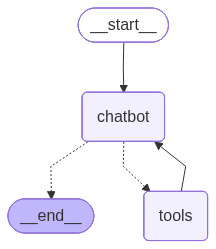

In [ ]:
from IPython.display import Image
display(Image(grafo.get_graph().draw_mermaid_png()))

## Consultas de prueba

In [ ]:
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage

def responder_usuario(user_input: str) -> str:
  """ Ejecuta el grafo con la entrada del usuario y retorna la respuesta final. """

  result = grafo.invoke({"messages": [{"role": "user", "content": user_input}]})

  # Extraer el último mensaje del asistente
  final_message = result["messages"][-1]

  if isinstance(final_message, AIMessage):
      return final_message.content
  else:
      return str(final_message.get("content", ""))


consultas = [
    "Hola, ¿cómo estás?",
    "Bien, muchas gracias. Mi color favorito es el azul",
    "¿Cuáles son 3 películas estrenadas en los años 2000?",
    "Qué dice uno de los papers sobre el uso de embeddings en RAG?",
    "Cuales son algunas películas hechas en USA?",
    "Gracias! Contame primero sobre embeddings y después respondé ¿cuál era mi color favorito?",
    "Cuales son algunas películas hechas en España de terror?",
    "Me podes repetir la respuesta más reciente que me diste?",
    "Haz un resumen sobre la ventaja del uso de embeddings y decime la fuente",
    "Gracias!"
]

for q in consultas:
    print(f"\n🧑‍💬 Usuario: {q}")
    print(f"🤖 Agente: {responder_usuario(q)}")


🧑‍💬 Usuario: Hola, ¿cómo estás?
🤖 Agente: Hola, estoy bien, gracias por preguntar 😊 ¿Y tú cómo estás?

🧑‍💬 Usuario: Bien, muchas gracias. Mi color favorito es el azul
🤖 Agente: Interesante, el azul es un color muy elegante y tranquilo. ¿Te gustaría que te recomiende alguna película con un tono o ambiente relacionado con el azul? Por ejemplo, películas con escenas de mar, cielos azules o incluso con un estilo visual que refleje ese color. 😊

🧑‍💬 Usuario: ¿Cuáles son 3 películas estrenadas en los años 2000?
🤖 Agente: Aquí tienes 3 películas estrenadas en los años 2000:

1. **La Ciénaga** (Argentina, 2001)  
   - Duración: 101 minutos  
   - Género principal: Fascinante  
   - Idioma: Español  
   - Escala de producción: Independiente  

2. **Okupas** (Argentina, 2000)  
   - Duración: 440 minutos  
   - Género principal: Crimen  
   - Idioma: Español  
   - Escala de producción: Épica  

3. **Common Wealth** (España, 2000)  
   - Duración: 109 minutos  
   - Género principal: Comedia  


Mismas consultas, imprimiendo ejecución y proceso de respuesta

In [ ]:
def stream_tool_responses_format(user_input: str):
    print("\n" + "="*80)
    print(f"🧑‍💬 Usuario: {user_input}")
    print("="*80 + "\n")

    seen_tool_calls = False
    printed_final_answer = False

    for event in grafo.stream({"messages": [("user", user_input)]}):

        for node_name, value in event.items():


            print(f"🧩 Nodo ejecutado: **{node_name}**")

            if not value or "messages" not in value:
                continue

            for msg in value["messages"]:
                content = getattr(msg, "content", None)

                if content and not isinstance(msg, dict) and es_smalltalk(content):
                    print("💬 (El agente DETECTÓ que este mensaje es **smalltalk**)\n")

                if isinstance(msg, HumanMessage):
                    continue

                if isinstance(msg, AIMessage):

                    if getattr(msg, "tool_calls", None):
                        if not seen_tool_calls:
                            tool_name = msg.tool_calls[0]["name"]
                            print(f"🤖 El agente decidió usar la herramienta 🛠️ **{tool_name}**\n")
                            seen_tool_calls = True
                        continue

                    if content and not printed_final_answer:
                        print(f"💬 Respuesta del agente:\n{content}\n")
                        printed_final_answer = True

                elif isinstance(msg, ToolMessage):
                    print(f"🔧 Resultado de herramienta ({msg.name}):")
                    texto = msg.content
                    if len(texto) > 900:
                        texto = texto[:900] + "..."
                    print(texto + "\n")

                elif isinstance(msg, dict):
                    continue


consultas = [
    "Hola, ¿cómo estás?",
    "Bien, muchas gracias. Mi color favorito es el azul",
    "¿Cuáles son 3 películas estrenadas en los años 2000?",
    "Qué dice uno de los papers sobre el uso de embeddings en RAG?",
    "Cuales son algunas películas hechas en USA?",
    "Gracias! Contame primero sobre embeddings y después respondé ¿cuál era mi color favorito?",
    "Cuales son algunas películas hechas en España de terror?",
    "Me podes repetir la respuesta más reciente que me diste?",
    "Haz un resumen sobre la ventaja del uso de embeddings y decime la fuente",
    "Gracias!"
]

for q in consultas:
    stream_tool_responses_format(q)


🧑‍💬 Usuario: Hola, ¿cómo estás?

🧩 Nodo ejecutado: **chatbot**
💬 (El agente DETECTÓ que este mensaje es **smalltalk**)


🧑‍💬 Usuario: Bien, muchas gracias. Mi color favorito es el azul

🧩 Nodo ejecutado: **chatbot**
💬 Respuesta del agente:
Interesante, el azul es un color muy elegante y tranquilo. ¿Te gustaría que exploráramos alguna película o tema relacionado con el azul? Por ejemplo, hay películas que utilizan el azul como tono principal o simbolismo. ¿Te interesaría eso? 😊


🧑‍💬 Usuario: ¿Cuáles son 3 películas estrenadas en los años 2000?

🧩 Nodo ejecutado: **chatbot**
🤖 El agente decidió usar la herramienta 🛠️ **buscar_peliculas**

🧩 Nodo ejecutado: **tools**
🔧 Resultado de herramienta (buscar_peliculas):
Resultados encontrados en el dataset de películas:
- The film La Ciénaga from Argentina was released in the year 2001 (decade: 2000s, era: Digital). Its duration is 101 minutes. It was produced in Argentina, and its language is Spanish. The production scale is Independent. It b

## Interfaz con **Gradio**

In [ ]:
agent_state = AgentState()
def gradio_responder(mensaje, historial):
  global agent_state, global_memory
  # Llamar al grafo con el estado persistente
  result = grafo.invoke({"messages": [{"role": "user", "content": mensaje}]}, state=agent_state)
  # Extraer respuesta final
  final_msg = result["messages"][-1]
  respuesta = final_msg.content if hasattr(final_msg, "content") else str(final_msg.get("content", ""))
  # Guardar interacción en memoria
  agent_state = guardar_memoria(agent_state, mensaje, respuesta)
  # Actualizar historial para Gradio
  historial.append((mensaje, respuesta))
  return historial

In [ ]:
import gradio as gr

css = """
#mi_chat {
    border: 2px solid #4CAF50;
    border-radius: 10px;
}
#mi_entrada {
    font-size: 16px;
    color: #333;
}
#mi_btn {
    background-color: #4CAF50;
    color: white;
    border-radius: 5px;
}
"""

with gr.Blocks(css=css) as demo:
    gr.Markdown("## chatbot (Películas + Papers + Memoria)")

    chat = gr.Chatbot(height=450, elem_id="mi_chat")
    entrada = gr.Textbox(label="Escribí tu mensaje", placeholder="Hola! ¿Qué tal?", elem_id="mi_entrada")
    btn = gr.Button("Enviar", elem_id="mi_btn")

    def boton_enviar(mensaje, historial):
        return gradio_responder(mensaje, historial)

    btn.click(boton_enviar, inputs=[entrada, chat], outputs=chat)
    entrada.submit(boton_enviar, inputs=[entrada, chat], outputs=chat)

demo.launch(share=True) #(debug=True) para ver errores

/tmp/ipython-input-3520165493.py:19: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css) as demo:
/tmp/ipython-input-3520165493.py:22: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chat = gr.Chatbot(height=450, elem_id="mi_chat")
/tmp/ipython-input-3520165493.py:22: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chat = gr.Chatbot(height=450, elem_id="mi_chat")


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://74aa73023060662f56.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
